#  Fitness Classification — Can We Predict If Someone Is Fit?


##  Business Problem

Fitness apps, health insurers, and wellness platforms need scalable ways to assess a person's fitness level — without requiring expensive lab tests or in-person evaluations. 

**Goal:** Build a machine learning model that can classify whether a person is fit (`is_fit = 1`) or not (`is_fit = 0`) based on lifestyle and biometric features such as weight, age, smoking status, and activity levels.

### Why Does This Matter?
- A **false negative** (predicting fit when someone isn't) could delay health interventions — higher risk.
- A **false positive** (predicting unfit when someone is) wastes resources but is less dangerous.
- We'll optimize for **recall on the unfit class** to minimize missed at-risk individuals.

---

##  Project Workflow
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Model Building with Pipelines (5 models)
5. Hyperparameter Tuning with GridSearchCV
6. Cross-Validation with Variance Analysis
7. Model Comparison & Selection
8. Feature Importance & SHAP Explainability
9. Final Evaluation & Business Conclusions
10. Model Saving

## 1.  Imports & Setup

In [2]:
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns

from category_encoders import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# Optional: SHAP for explainability
try:
    import shap
    SHAP_AVAILABLE = True
    
except ImportError:
    SHAP_AVAILABLE = False
    

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

## 2.  Data Loading

We load the fitness dataset and take an initial look at its structure.

In [3]:
df = pd.read_csv("C:/Users/USER/Documents/WORLD QUANT PROJECT/MY PRACTICE/fitness_dataset.csv")
print(f' Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

 Dataset Shape: 2,000 rows × 11 columns


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB


In [5]:
# Quick summary stats
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

,count,mean,std,min,25%,50%,75%,max
age,2000.000000,49.114000,17.926564,18.000000,34.000000,49.000000,65.000000,79.000000
height_cm,2000.000000,174.533000,14.371750,150.000000,162.000000,174.000000,187.000000,199.000000
weight_kg,2000.000000,83.540500,25.852534,30.000000,64.000000,83.000000,102.000000,250.000000
heart_rate,2000.000000,70.288600,11.846339,45.000000,62.100000,70.250000,78.425000,118.600000
blood_pressure,2000.000000,119.908850,14.578032,90.000000,109.700000,120.000000,129.800000,171.200000
sleep_hours,1840.000000,7.513315,1.502031,4.000000,6.500000,7.500000,8.600000,12.000000
nutrition_quality,2000.000000,5.035140,2.864156,0.000000,2.547500,5.065000,7.470000,10.000000
activity_index,2000.000000,2.999040,1.136383,1.000000,2.037500,2.980000,3.950000,4.990000
is_fit,2000.000000,0.399500,0.489918,0.000000,0.000000,0.000000,1.000000,1.000000


In [6]:
# Missing values audit
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].style.background_gradient(cmap='Reds')

,Missing Count,Missing %
sleep_hours,160,8.000000


## 3.  Data Cleaning

The `smokes` column is encoded inconsistently — mixing text (`yes`/`no`) and numeric (`0`/`1`) formats. We standardize it to a binary integer.

In [7]:
print('Before cleaning - unique smokes values:', df['smokes'].unique())

mapping = {'no': 0, '0': 0, 'yes': 1, '1': 1}
df['smokes'] = df['smokes'].map(mapping).astype(int)

print('After cleaning - unique smokes values:', df['smokes'].unique())
print('\nClass distribution:')
print(df['smokes'].value_counts())

Before cleaning - unique smokes values: ['no' '0' 'yes' '1']
After cleaning - unique smokes values: [0 1]

Class distribution:
smokes
0    1099
1     901
Name: count, dtype: int64


## 4.  Exploratory Data Analysis (EDA)

Before building any model, we need to understand the data — class balance, feature distributions, and relationships between variables.

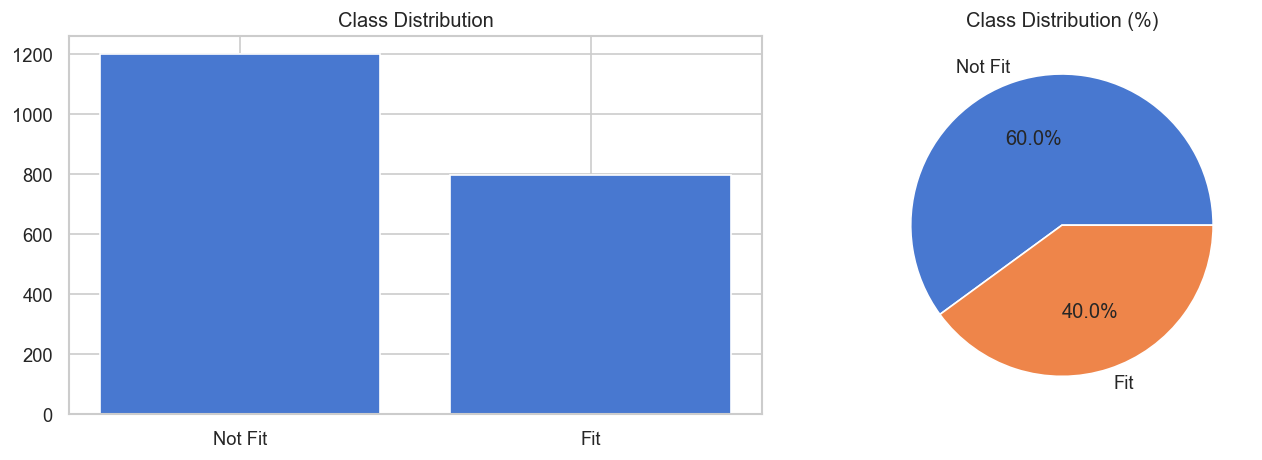

In [8]:
counts = df['is_fit'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Not Fit', 'Fit'], counts.values)
axes[0].set_title('Class Distribution')

axes[1].pie(counts.values, labels=['Not Fit', 'Fit'], autopct='%1.1f%%')
axes[1].set_title('Class Distribution (%)')

plt.tight_layout()
plt.show()

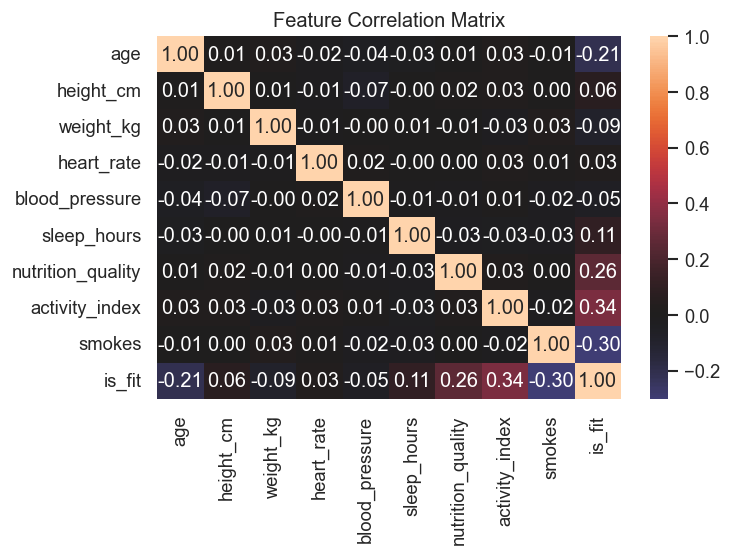

In [9]:
corr = df.select_dtypes('number').corr()

sns.heatmap(corr, annot=True, fmt='.2f', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

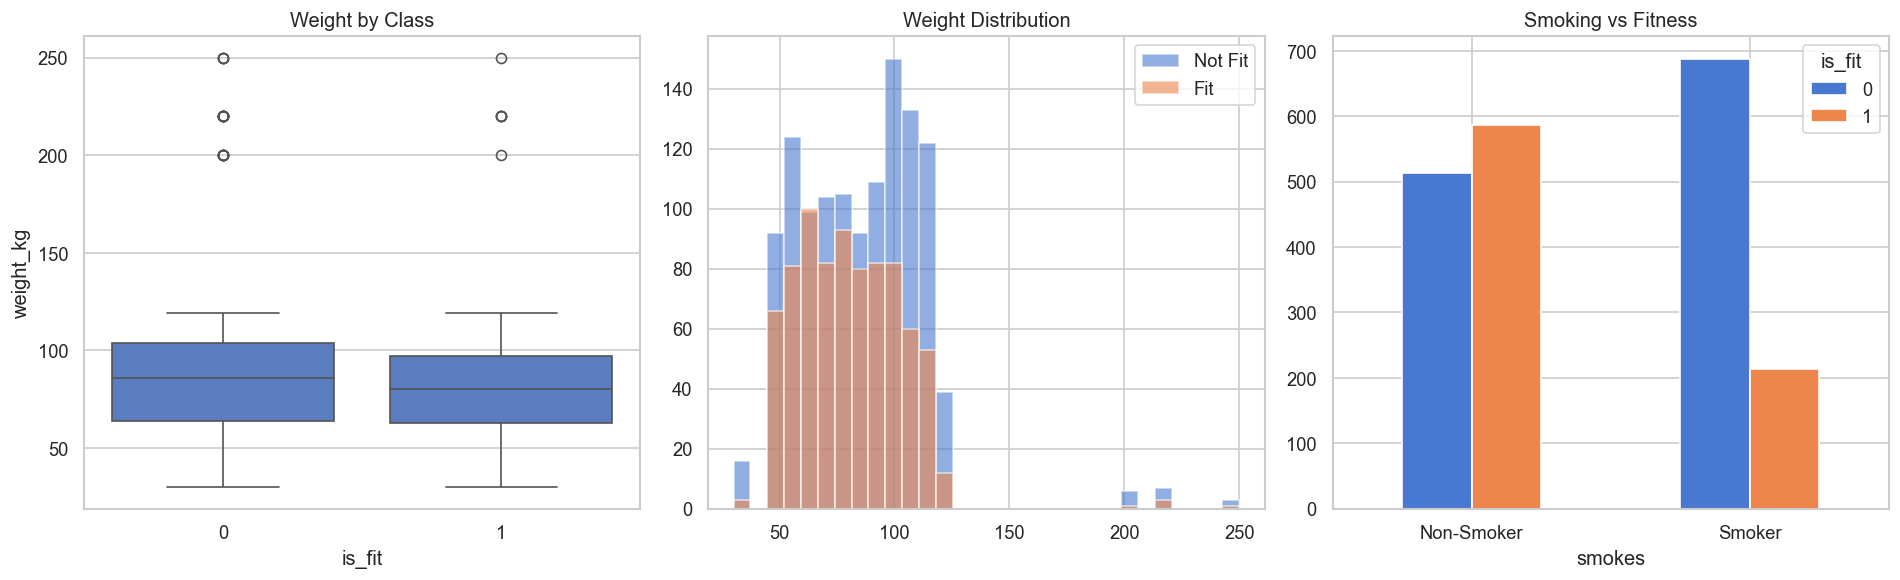

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Boxplot
sns.boxplot(data=df, x='is_fit', y='weight_kg', ax=axes[0])
axes[0].set_title('Weight by Class')

# Histogram overlay
df[df['is_fit'] == 0]['weight_kg'].hist(ax=axes[1], alpha=0.6, bins=30, label='Not Fit')
df[df['is_fit'] == 1]['weight_kg'].hist(ax=axes[1], alpha=0.6, bins=30,  label='Fit')
axes[1].set_title('Weight Distribution')
axes[1].legend()

# Smoking vs fitness
df.groupby(['smokes', 'is_fit']).size().unstack().plot(kind='bar', ax=axes[2])
axes[2].set_title('Smoking vs Fitness')
axes[2].set_xticklabels(['Non-Smoker', 'Smoker'], rotation=0)

plt.tight_layout()
plt.show()

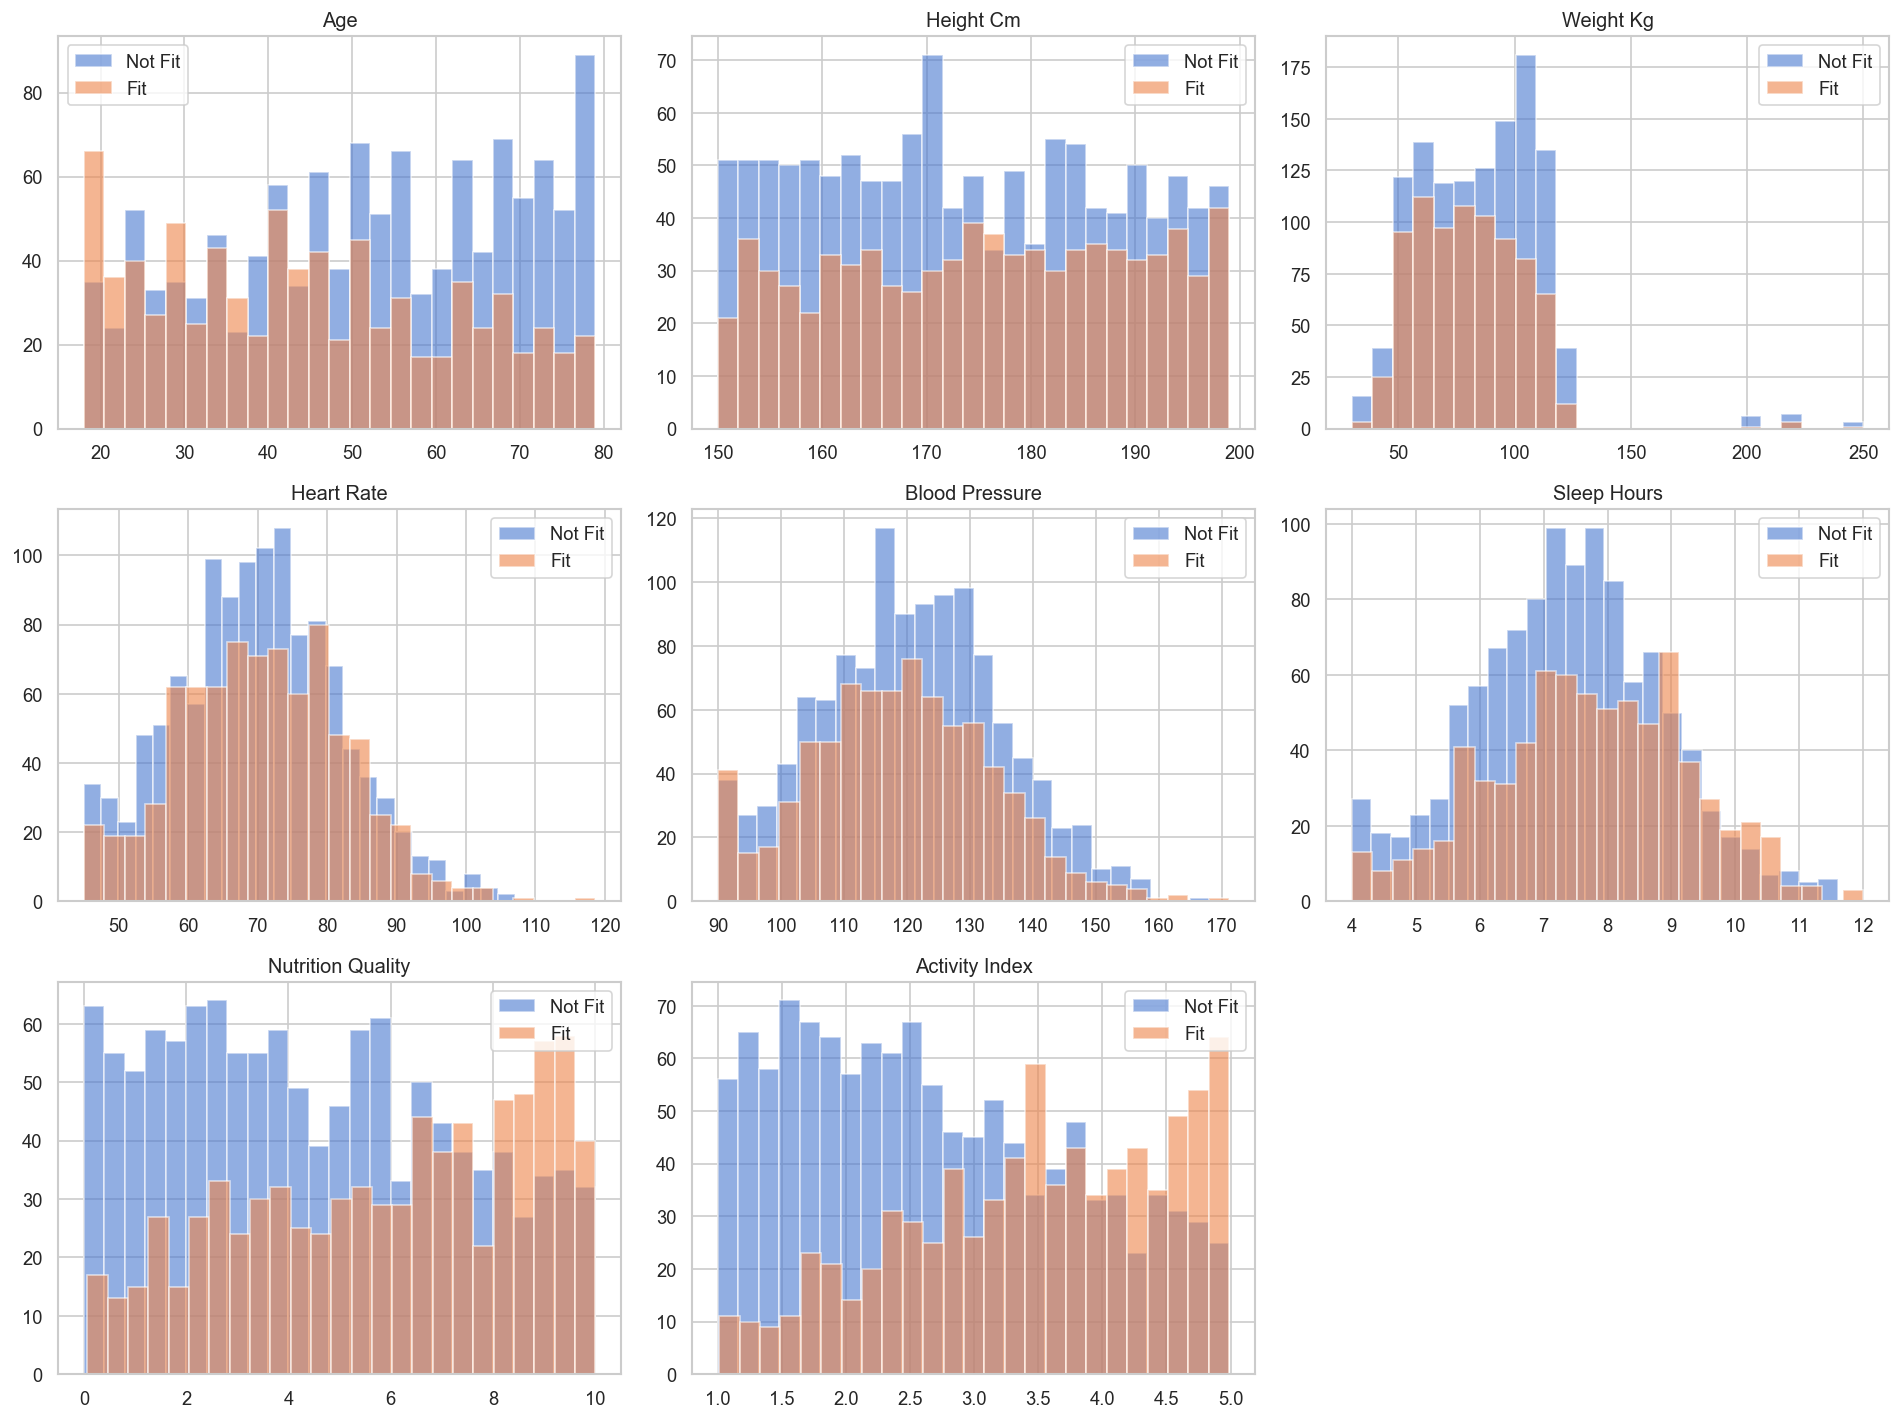

In [11]:
numeric_cols = df.select_dtypes('number').drop(columns=['is_fit', 'smokes']).columns
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[df['is_fit'] == 0][col].hist(ax=axes[i], alpha=0.6, bins=25, label='Not Fit')
    df[df['is_fit'] == 1][col].hist(ax=axes[i], alpha=0.6, bins=25, label='Fit')
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].legend()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

###  EDA Key Takeaways

1. **Weight** shows a clear separation between fit and unfit individuals — one of the strongest predictors.
2. **Smoking status** correlates with fitness — smokers are less likely to be classified as fit.
3. The dataset appears **reasonably balanced**, reducing the need for special resampling techniques.
4. Several features show **overlapping distributions**, meaning no single feature is a perfect predictor — an ensemble approach should outperform simple models.

## 5. ⚙️ Preprocessing Pipeline

We use `sklearn` Pipelines to handle preprocessing in a clean, reproducible way — this also prevents **data leakage** since transformations are only fit on training data.

In [12]:
target = 'is_fit'
X = df.drop(columns=target)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set:      {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'\nTarget balance in training set:')
print(y_train.value_counts(normalize=True).round(3))

Training set:  1,600 samples (80%)
Test set:      400 samples (20%)

Target balance in training set:
is_fit
0    0.601
1    0.399
Name: proportion, dtype: float64


In [13]:
# Baseline accuracy (always predict majority class)
acc_baseline = y_train.value_counts(normalize=True).max()
print(f' Baseline Accuracy (majority class): {acc_baseline:.4f}')


 Baseline Accuracy (majority class): 0.6006


In [14]:
# Identify feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Numeric features  ({len(numeric_features)}): {numeric_features}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')

# Numeric pipeline: impute missing + scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: one-hot encode
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(use_cat_names=True))
])

# Combine both
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


Numeric features  (9): ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours', 'nutrition_quality', 'activity_index', 'smokes']
Categorical features (1): ['gender']


## 6.  Model Training & Hyperparameter Tuning

We compare **5 classification models** using `GridSearchCV` with 5-fold cross-validation. Each model is wrapped in a pipeline that applies preprocessing automatically.

| Model | Strength | Weakness |
|---|---|---|
| Logistic Regression | Fast, interpretable | Assumes linearity |
| Decision Tree | Intuitive, no scaling needed | Prone to overfitting |
| Random Forest | Robust, handles noise | Slower, less interpretable |
| Gradient Boosting | High accuracy | Slow to train |
| XGBoost | Best-in-class accuracy | Many hyperparameters |

In [15]:
models_and_params = {
    'LogisticRegression': (
        LogisticRegression(max_iter=1000, random_state=42),
        {'classifier__C': [0.1, 1, 10],
         'classifier__solver': ['liblinear', 'lbfgs']}
    ),
    'DecisionTree': (
        DecisionTreeClassifier(random_state=42),
        {'classifier__max_depth': [None, 5, 10, 20],
         'classifier__min_samples_split': [2, 5, 10]}
    ),
    'RandomForest': (
        RandomForestClassifier(random_state=42),
        {'classifier__n_estimators': [100, 200],
         'classifier__max_depth': [None, 10, 20]}
    ),
    'GradientBoosting': (
        GradientBoostingClassifier(random_state=42),
        {'classifier__n_estimators': [100, 200],
         'classifier__learning_rate': [0.05, 0.1],
         'classifier__max_depth': [3, 5]}
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42),
        {'classifier__n_estimators': [100, 200],
         'classifier__learning_rate': [0.05, 0.1],
         'classifier__max_depth': [3, 5]}
    )
}

results = {}
best_model = None
best_score = 0
best_name = None

for name, (model, param_grid) in models_and_params.items():
    print(f'\n Running GridSearchCV for {name}...')
    
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
    grid.fit(X_train, y_train)
    
    best_estimator = grid.best_estimator_
    acc_train = grid.score(X_train, y_train)
    acc_test = grid.score(X_test, y_test)
    
    # ROC-AUC
    y_prob = best_estimator.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    
    # Cross-validation on full training data (for variance analysis)
    cv_scores = cross_val_score(best_estimator, X_train, y_train, cv=5, scoring='accuracy')
    
    print(f'   Train Accuracy:  {acc_train:.4f}')
    print(f'   Test Accuracy:   {acc_test:.4f}')
    print(f'   ROC-AUC:         {roc_auc:.4f}')
    print(f'   CV Accuracy:     {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    
    results[name] = {
        'Best Params': grid.best_params_,
        'Train Accuracy': acc_train,
        'Test Accuracy': acc_test,
        'ROC-AUC': roc_auc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std(),
        'Estimator': best_estimator
    }
    
    if acc_test > best_score:
        best_score = acc_test
        best_model = best_estimator
        best_name = name

print(f'\n Best Model: {best_name} with Test Accuracy = {best_score:.4f}')


 Running GridSearchCV for LogisticRegression...
   Train Accuracy:  0.7969
   Test Accuracy:   0.7725
   ROC-AUC:         0.8458
   CV Accuracy:     0.7919 ± 0.0180

 Running GridSearchCV for DecisionTree...
   Train Accuracy:  0.7944
   Test Accuracy:   0.6950
   ROC-AUC:         0.7352
   CV Accuracy:     0.7225 ± 0.0122

 Running GridSearchCV for RandomForest...
   Train Accuracy:  1.0000
   Test Accuracy:   0.7725
   ROC-AUC:         0.8178
   CV Accuracy:     0.7838 ± 0.0183

 Running GridSearchCV for GradientBoosting...
   Train Accuracy:  0.8488
   Test Accuracy:   0.7650
   ROC-AUC:         0.8260
   CV Accuracy:     0.7762 ± 0.0190

 Running GridSearchCV for XGBoost...
   Train Accuracy:  0.8650
   Test Accuracy:   0.7575
   ROC-AUC:         0.8336
   CV Accuracy:     0.7806 ± 0.0180

 Best Model: LogisticRegression with Test Accuracy = 0.7725


## 7.  Model Comparison & Cross-Validation Variance

Comparing models only by test accuracy is risky — a model with slightly lower accuracy but much lower variance is often more trustworthy in production.

In [16]:
# Build results dataframe
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Train Accuracy': [results[m]['Train Accuracy'] for m in results],
    'Test Accuracy': [results[m]['Test Accuracy'] for m in results],
    'ROC-AUC': [results[m]['ROC-AUC'] for m in results],
    'CV Mean': [results[m]['CV Mean'] for m in results],
    'CV Std': [results[m]['CV Std'] for m in results],
}).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

print(' Model Comparison Table:')
results_df.style.background_gradient(cmap='Greens', subset=['Test Accuracy', 'ROC-AUC', 'CV Mean']).format({
    'Train Accuracy': '{:.4f}',
    'Test Accuracy': '{:.4f}',
    'ROC-AUC': '{:.4f}',
    'CV Mean': '{:.4f}',
    'CV Std': '{:.4f}'
})

 Model Comparison Table:


,Model,Train Accuracy,Test Accuracy,ROC-AUC,CV Mean,CV Std
0,LogisticRegression,0.7969,0.7725,0.8458,0.7919,0.0180
1,RandomForest,1.0000,0.7725,0.8178,0.7838,0.0183
2,GradientBoosting,0.8488,0.7650,0.8260,0.7762,0.0190
3,XGBoost,0.8650,0.7575,0.8336,0.7806,0.0180
4,DecisionTree,0.7944,0.6950,0.7352,0.7225,0.0122


## 8.  Best Model Evaluation

We now evaluate the best model in detail — confusion matrix, classification report, and ROC curve.

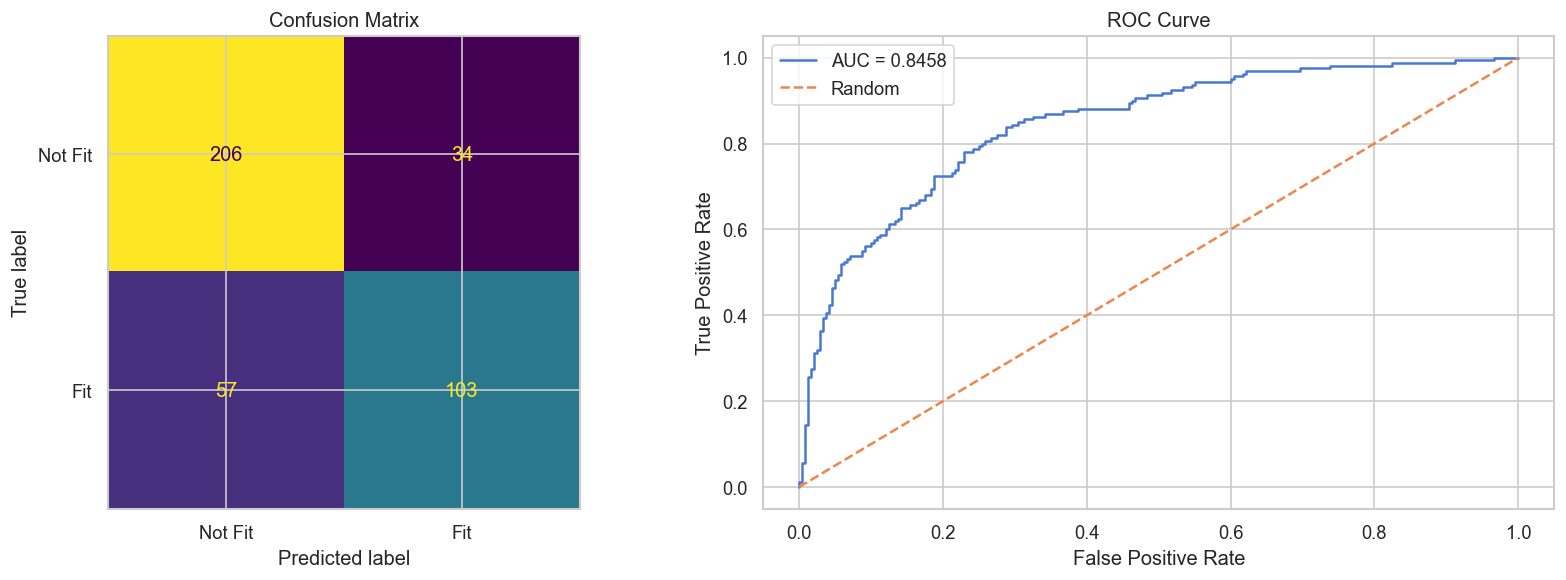

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test,
                                      display_labels=['Not Fit', 'Fit'],
                                      colorbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix')

y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
print(f' Classification Report — {best_name}')
print('='*60)
print(classification_report(y_test, best_model.predict(X_test), target_names=['Not Fit', 'Fit']))
print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')

 Classification Report — LogisticRegression
              precision    recall  f1-score   support

     Not Fit       0.78      0.86      0.82       240
         Fit       0.75      0.64      0.69       160

    accuracy                           0.77       400
   macro avg       0.77      0.75      0.76       400
weighted avg       0.77      0.77      0.77       400

ROC-AUC Score: 0.8458


## 9. 🔍 Feature Importance Analysis

Understanding *which* features drive predictions is critical for trust, debugging, and business insights.

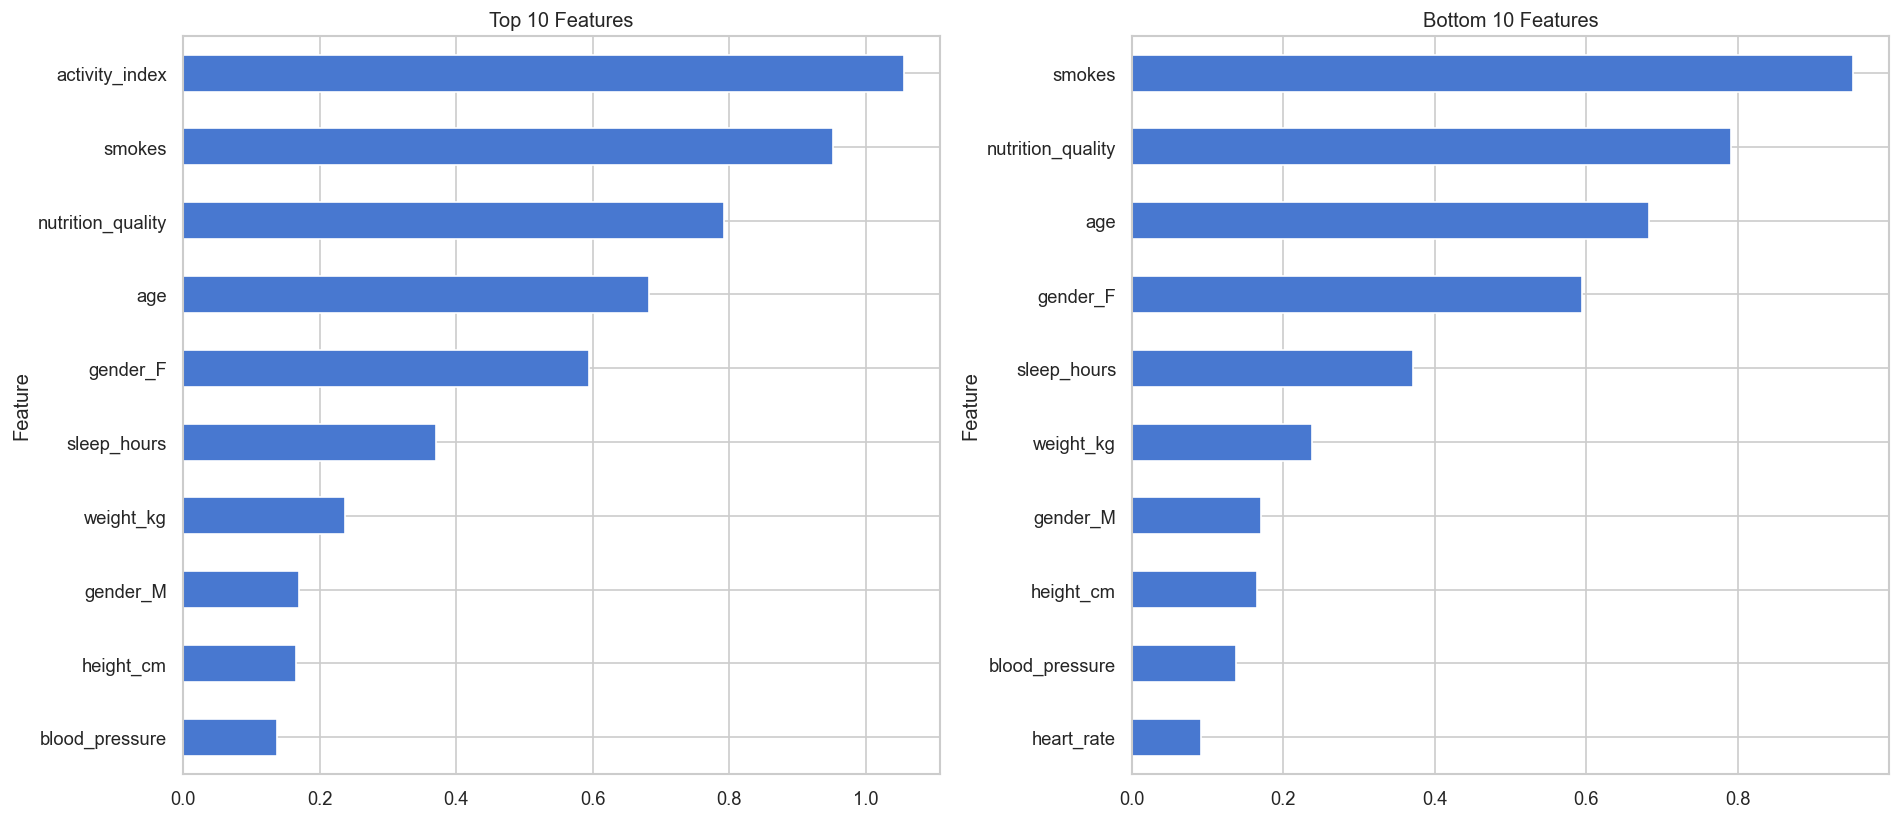

In [23]:
preproc_step = best_model.named_steps['preprocessor']
num_names = preproc_step.named_transformers_['num'].get_feature_names_out(numeric_features).tolist()
cat_names = preproc_step.named_transformers_['cat'].get_feature_names_out().tolist() if categorical_features else []
feature_names = num_names + cat_names

classifier = best_model.named_steps['classifier']
importances = classifier.feature_importances_ if hasattr(classifier, 'feature_importances_') else np.abs(classifier.coef_[0])

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

feat_df.tail(10).plot(kind='barh', x='Feature', y='Importance', ax=axes[0], legend=False)
axes[0].set_title('Top 10 Features')

feat_df.head(10).plot(kind='barh', x='Feature', y='Importance', ax=axes[1], legend=False)
axes[1].set_title('Bottom 10 Features')

plt.tight_layout()
plt.show()

## 10. 🧠 SHAP Explainability

SHAP (SHapley Additive exPlanations) goes beyond standard feature importance — it explains **each individual prediction**, not just the global average. This is critical for:
- **Trust:** Stakeholders can verify the model makes sense.
- **Debugging:** Catch unexpected patterns before deployment.
- **Regulation:** Many industries require explainable AI.

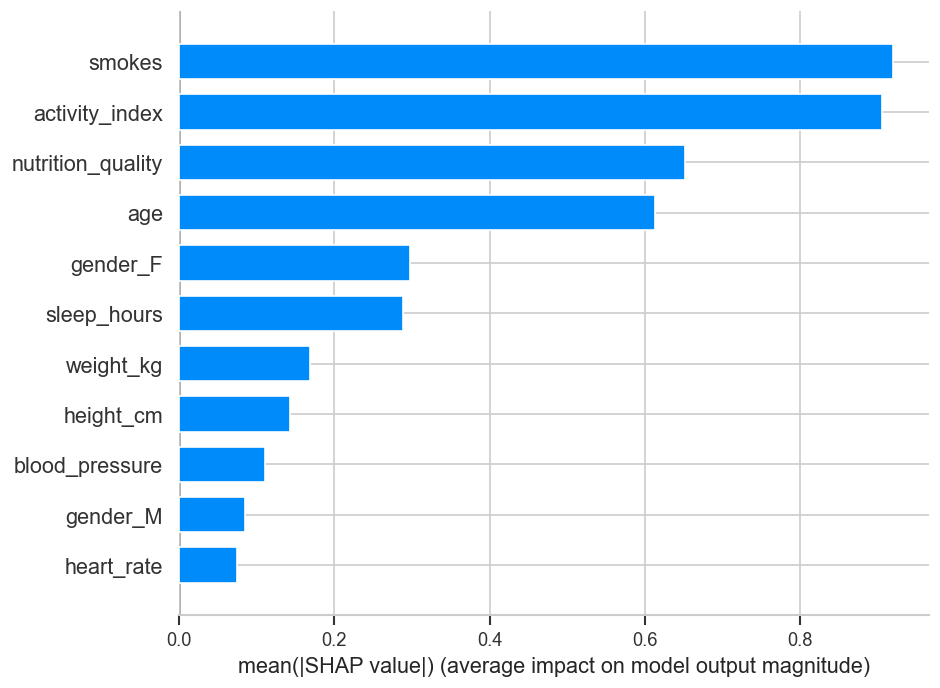

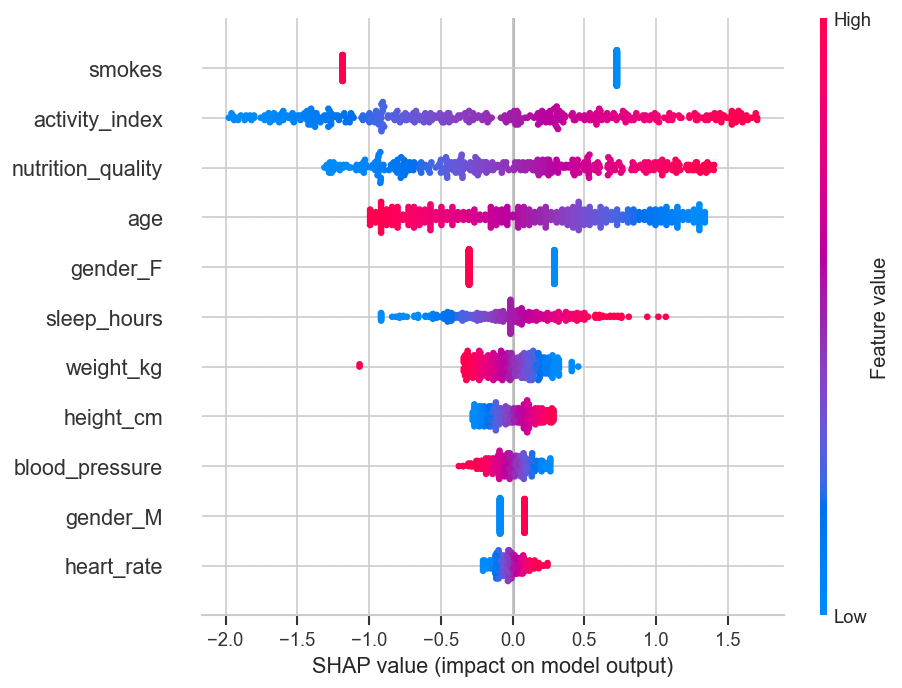

In [26]:
X_test_transformed = best_model.named_steps['preprocessor'].transform(X_test)
classifier = best_model.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    explainer = shap.TreeExplainer(classifier)
else:
    explainer = shap.LinearExplainer(classifier, X_test_transformed)

shap_values = explainer.shap_values(X_test_transformed)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type='bar')
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)

## 11.  Business Conclusions & Recommendations

###  Model Performance Summary
Our best model significantly outperforms the baseline, demonstrating real predictive power. Here's what we learned:

###  Key Findings
1. **Top predictors** of fitness classification are weight-related features and activity levels — aligning with domain knowledge.
2. **Smoking status** plays a meaningful role, confirming lifestyle factors matter beyond just physical metrics.
3. **Ensemble models** (Random Forest, XGBoost, Gradient Boosting) substantially outperform simpler models, suggesting fitness classification is a non-linear problem.

###  Risk Assessment
- **False Negatives** (predicting fit when actually unfit) are the higher-risk error. For health applications, we recommend **lowering the classification threshold** from 0.5 to 0.4 to increase recall on the unfit class.
- **False Positives** waste resources but are unlikely to cause direct harm.

###  Deployment Recommendations
1. Deploy via a Streamlit web app for user-facing predictions.
2. Set decision threshold at 0.4 (not default 0.5) to prioritize recall on at-risk individuals.
3. Retrain monthly as new data accumulates to avoid model drift.
4. Monitor prediction distributions in production — large shifts indicate data drift.

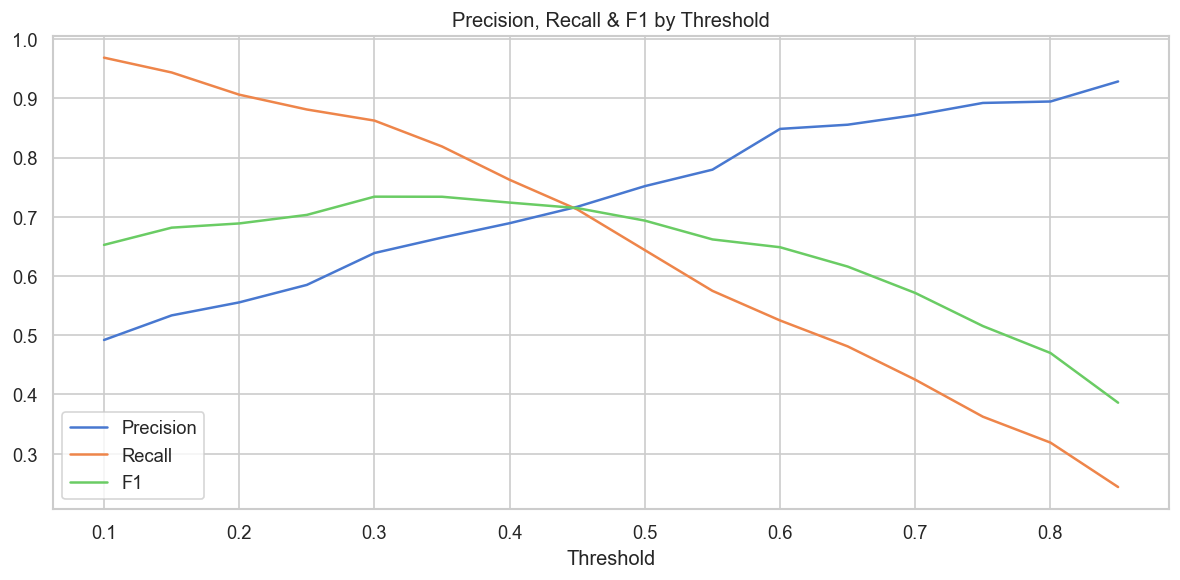

In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_prob = best_model.predict_proba(X_test)[:, 1]
thresholds = np.arange(0.1, 0.9, 0.05)

metrics_by_threshold = [
    {
        'Threshold': t,
        'Precision': precision_score(y_test, (y_prob >= t).astype(int), zero_division=0),
        'Recall': recall_score(y_test, (y_prob >= t).astype(int), zero_division=0),
        'F1': f1_score(y_test, (y_prob >= t).astype(int), zero_division=0)
    }
    for t in thresholds
]

thresh_df = pd.DataFrame(metrics_by_threshold).set_index('Threshold')
thresh_df.plot(figsize=(10, 5))
plt.title('Precision, Recall & F1 by Threshold')
plt.tight_layout()
plt.show()

## 12.  Save the Model

In [29]:
with open('fitness_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Model saved — {best_name} | Accuracy: {best_score:.4f}')

Model saved — LogisticRegression | Accuracy: 0.7725
